### Network Anomaly Detection using XGBoost

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.utils.multiclass import unique_labels
from sklearn.utils import resample
import xgboost as xgb
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt

# datapath
datapath = 'D:/r6g/prog1/cicids2018M2/setb/'

In [2]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
    "Train": datapath+"boruta_train.csv",
    "Validation": datapath+"boruta_validation.csv",
    "Test": datapath+"boruta_test.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)


Loaded datasets:
Train: (10415285, 22)
Test: (2714727, 22)
Validation: (2603822, 22)

Final shapes:
X_train: (10415285, 20)  | y_train: (10415285,)
X_val: (2603822, 20)  | y_val: (2603822,)
X_test: (2714727, 20)  | y_test: (2714727,)


In [3]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("🔍 Starting validation-based hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            # Train on training set
            model.fit(X_train, y_train)

            # Validate
            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            # Track best
            if val_acc > best_score:
                best_score = val_acc
                best_params = {'n_estimators': n, 'max_depth': md, 'learning_rate': lr}
                best_model = model

print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)

joblib.dump(best_model, datapath+"xgb_best_model.pkl")




🔍 Starting validation-based hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:28:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98584

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:29:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98854

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:33:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98917

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:37:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98918

Best Params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2}
Best Validation Accuracy: 0.9891839764776548


['D:/r6g/prog1/cicids2018M2/setb/xgb_best_model.pkl']

Loading model
Test metrics:
  Accuracy : 0.9835
  Precision: 0.9851
  Recall   : 0.9835
  F1-Score : 0.9828

Confusion Matrix (Raw Values):
[[2425654       4       0       4       1    2881       9]
 [      1   45982       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [      0       0       0   91141       0       0       0]
 [    153       0   24703       0   94595       0       0]
 [  17049       0       0       0       0     405       0]
 [     26       0       0       0       0       0     107]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2425654,4,0,4,1,2881,9
True Bot,1,45982,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,0,0,0,91141,0,0,0
True DoS,153,0,24703,0,94595,0,0
True Infiltration,17049,0,0,0,0,405,0
True Web Attack,26,0,0,0,0,0,107


<Figure size 1200x800 with 0 Axes>

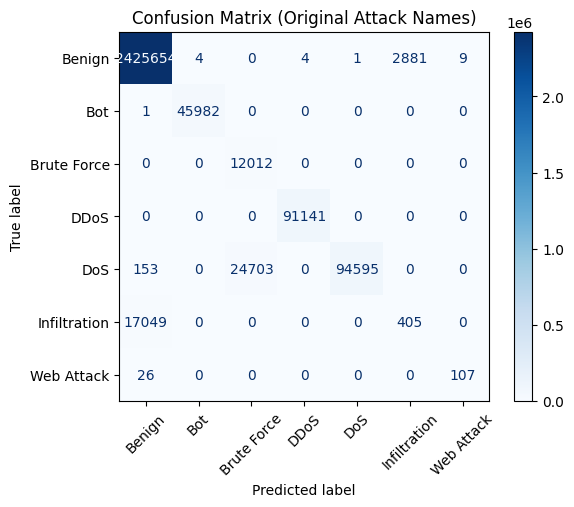

In [4]:
# Load and run best model to verify the result
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_best_model.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open("D:/r6g/prog1/cicids2018M2/mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()


### XGBoost With Downsampling

In [5]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
    "Train": datapath+"boruta_train.csv",
    "Validation": datapath+"boruta_validation.csv",
    "Test": datapath+"boruta_test.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)

Loaded datasets:
Train: (10415285, 22)
Test: (2714727, 22)
Validation: (2603822, 22)

Final shapes:
X_train: (10415285, 20)  | y_train: (10415285,)
X_val: (2603822, 20)  | y_val: (2603822,)
X_test: (2714727, 20)  | y_test: (2714727,)


In [6]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# ------------ Downsampling -----------------
train_data = X_train.copy()
train_data['Attack_Type'] = y_train.values

majority_class = train_data[train_data['Attack_Type'] == train_data['Attack_Type'].value_counts().idxmax()]
minority_class = train_data[train_data['Attack_Type'] != train_data['Attack_Type'].value_counts().idxmax()]

majority_downsampled = resample(
    majority_class,
    replace=False,
    n_samples=len(minority_class),
    random_state=42
)

train_balanced = pd.concat([majority_downsampled, minority_class])
X_train = train_balanced.drop(columns=['Attack_Type'])
y_train = train_balanced['Attack_Type']

# -----------------------------------------------------

best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("🔍 Starting validation-based hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            # Train on training set
            model.fit(X_train, y_train)

            # Validate
            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            # Track best
            if val_acc > best_score:
                best_score = val_acc
                best_params = {'n_estimators': n, 'max_depth': md, 'learning_rate': lr}
                best_model = model

print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)

joblib.dump(best_model, datapath+"xgb_DS_best_model.pkl")
print("Saved: xgb_DS_best_model.pkl")

🔍 Starting validation-based hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:42:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98333

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:42:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98682

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

 → Validation Accuracy: 0.98707

Testing: n_estimators=300, max_depth=7, learning_rate=0.1


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:01:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98687

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:03:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98656

Best Params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best Validation Accuracy: 0.9874388495066099
Saved: xgb_DS_best_model.pkl


Loading model
Test metrics:
  Accuracy : 0.9814
  Precision: 0.9853
  Recall   : 0.9814
  F1-Score : 0.9820

Confusion Matrix (Raw Values):
[[2419216      28      12     155      34    9090      18]
 [      0   45983       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [      0       0       0   91141       0       0       0]
 [    105       0   24703       0   94643       0       0]
 [  16212       0       0       1       0    1241       0]
 [     28       0       0       1       0       0     104]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2419216,28,12,155,34,9090,18
True Bot,0,45983,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,0,0,0,91141,0,0,0
True DoS,105,0,24703,0,94643,0,0
True Infiltration,16212,0,0,1,0,1241,0
True Web Attack,28,0,0,1,0,0,104


<Figure size 1200x800 with 0 Axes>

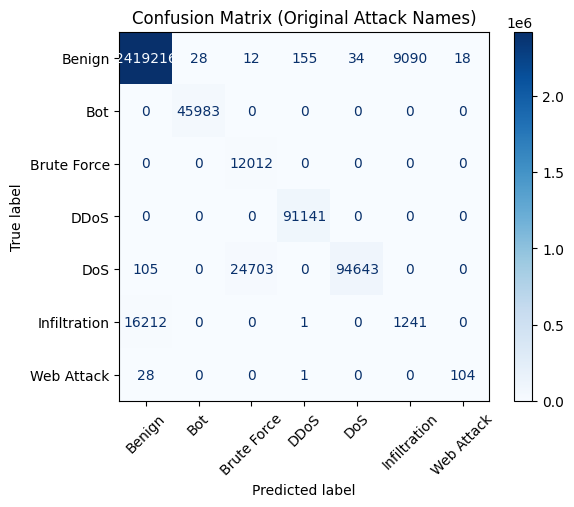

In [7]:
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_DS_best_model.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_DS_best_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open("D:/r6g/prog1/cicids2018M2/mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()


### XGBoost with SOMTE and Tomek Link 1

In [4]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
    "Train": datapath+"boruta_train.csv",
    "Validation": datapath+"boruta_validation.csv",
    "Test": datapath+"boruta_test.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)

Loaded datasets:
Train: (10415285, 22)
Test: (2714727, 22)
Validation: (2603822, 22)

Final shapes:
X_train: (10415285, 20)  | y_train: (10415285,)
X_val: (2603822, 20)  | y_val: (2603822,)
X_test: (2714727, 20)  | y_test: (2714727,)


📊 Distribution BEFORE:


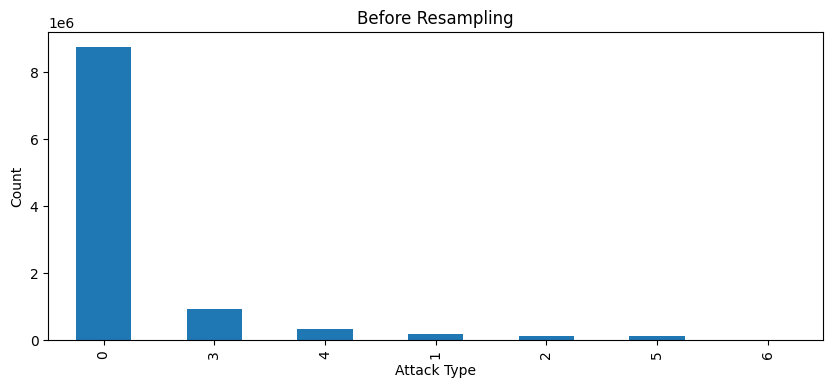

Original counts: Counter({0: 8757431, 3: 924193, 4: 313718, 1: 189061, 2: 115725, 5: 114521, 6: 636})
Label 5: from 114521 → 229042
Label 6: from 636 → 3180

After SMOTE:
Counter({0: 8757431, 3: 924193, 4: 313718, 5: 229042, 1: 189061, 2: 115725, 6: 3180})

💾 Saved cleaned training data → boruta_SM_TL_train.csv
📊 Distribution AFTER:


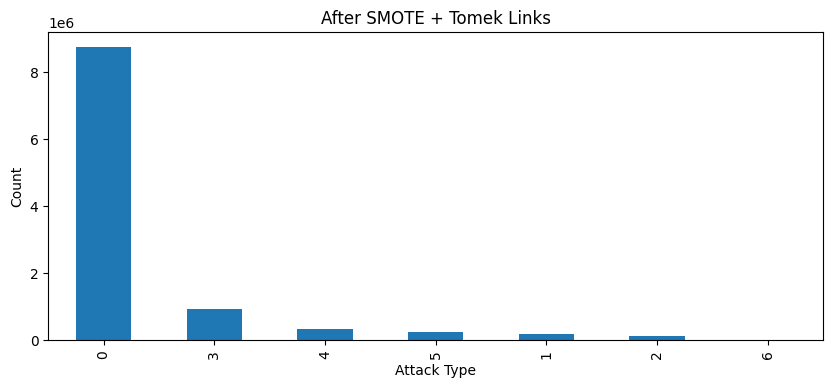


🔍 Starting XGBoost hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:33:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98658

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:35:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98838

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

 → Validation Accuracy: 0.98895

Testing: n_estimators=300, max_depth=7, learning_rate=0.1


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:37:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98898

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:42:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98894

Best Params: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.1}
Best Validation Accuracy: 0.9889969437234957

💾 Best model saved → D:/r6g/prog1/cicids2018M2/setb/xgb_SMOTE_Tomek_best_model1.pkl


In [5]:
# =====================================================
# Imports
# =====================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import accuracy_score
import xgboost as xgb
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# =====================================================
# Distribution Plot
# =====================================================
def plot_distribution(y, title):
    plt.figure(figsize=(10,4))
    pd.Series(y).value_counts().plot(kind='bar')
    plt.title(title)
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.show()


print("📊 Distribution BEFORE:")
plot_distribution(y_train, "Before Resampling")

print("Original counts:", Counter(y_train))


# =====================================================
# 1️⃣ SMOTE — Increase Label 5 (+100%) & Label 6 (+500%)
# =====================================================

orig_c5 = Counter(y_train)[5]
orig_c6 = Counter(y_train)[6]

# 100% increase → new count = 2 × original
target_c5 = orig_c5 * 2

# 500% increase → new count = 5 × original
target_c6 = orig_c6 * 5

print(f"Label 5: from {orig_c5} → {target_c5}")
print(f"Label 6: from {orig_c6} → {target_c6}")

smote_strategy = {
    5: target_c5,
    6: target_c6
}

sm = SMOTE(
    sampling_strategy=smote_strategy,
    k_neighbors=5,
    random_state=42
)

X_sm, y_sm = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(Counter(y_sm))


# # =====================================================
# # 2️⃣ Tomek Links — reduce majority classes
# # =====================================================
# tl = TomekLinks(sampling_strategy="majority")

# X_clean, y_clean = tl.fit_resample(X_sm, y_sm)

# print("\nAfter Tomek Links:")
# print(Counter(y_clean))

####### Bypass Tomek Links
X_clean = X_sm
y_clean = y_sm

# =====================================================
# 3️⃣ Save the cleaned training dataset
# =====================================================
boruta_SM_TL_train = pd.concat(
    [pd.DataFrame(X_clean, columns=X_train.columns),
     pd.Series(y_clean, name="Attack_Type")],
    axis=1
)

boruta_SM_TL_train.to_csv("boruta_SM_TL_train1.csv", index=False)
print("\n💾 Saved cleaned training data → boruta_SM_TL_train.csv")


# =====================================================
# 4️⃣ Plot final distribution
# =====================================================
print("📊 Distribution AFTER:")
plot_distribution(y_clean, "After SMOTE + Tomek Links")


# Replace training sets
X_train = X_clean
y_train = y_clean


# =====================================================
# 5️⃣ XGBoost Hyperparameter Search
# =====================================================
best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("\n🔍 Starting XGBoost hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            model.fit(X_train, y_train)

            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            if val_acc > best_score:
                best_score = val_acc
                best_params = {
                    'n_estimators': n,
                    'max_depth': md,
                    'learning_rate': lr
                }
                best_model = model


print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)


# =====================================================
# 6️⃣ Save the Best Model
# =====================================================
model_path = datapath+"xgb_SMOTE_Tomek_best_model1.pkl"
joblib.dump(best_model, model_path)
print(f"\n💾 Best model saved → {model_path}")


Loading model
Test metrics:
  Accuracy : 0.9826
  Precision: 0.9848
  Recall   : 0.9826
  F1-Score : 0.9824

Confusion Matrix (Raw Values):
[[2423257       5       0       3       3    5274      11]
 [      0   45983       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [      0       0       0   91141       0       0       0]
 [    106       0   24703       0   94642       0       0]
 [  16991       0       0       0       0     463       0]
 [     23       0       0       0       0       0     110]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2423257,5,0,3,3,5274,11
True Bot,0,45983,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,0,0,0,91141,0,0,0
True DoS,106,0,24703,0,94642,0,0
True Infiltration,16991,0,0,0,0,463,0
True Web Attack,23,0,0,0,0,0,110


<Figure size 1200x800 with 0 Axes>

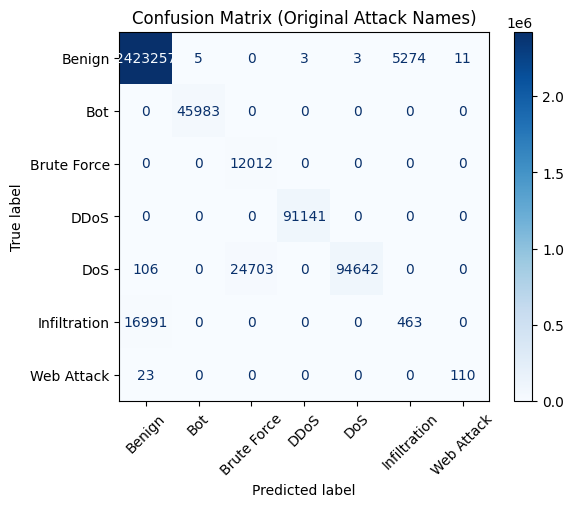

In [6]:
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_SMOTE_Tomek_best_model1.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_DS_best_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open("D:/r6g/prog1/cicids2018M2/mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()

### XGBoost with SOMTE and Tomek Link + downsampling

In [7]:
import pandas as pd

# =====================================================
# 1️⃣ File paths
# =====================================================
paths = {
    "Train": datapath+"boruta_train.csv",
    "Validation": datapath+"boruta_validation.csv",
    "Test": datapath+"boruta_test.csv"

}

# =====================================================
# 2️⃣ Read CSV files
# =====================================================
df_train = pd.read_csv(paths["Train"])
df_test = pd.read_csv(paths["Test"])
df_val = pd.read_csv(paths["Validation"])

print("Loaded datasets:")
print("Train:", df_train.shape)
print("Test:", df_test.shape)
print("Validation:", df_val.shape)

# =====================================================
# 3️⃣ Split into X and y
# =====================================================
# Training
X_train = df_train.drop(columns=["Label","Attack_Type"])
y_train = df_train["Attack_Type"]

# Validation
X_val = df_val.drop(columns=["Label", "Attack_Type"])
y_val = df_val["Attack_Type"]

# Testing
X_test = df_test.drop(columns=["Label","Attack_Type"])
y_test = df_test["Attack_Type"]

# =====================================================
# 4️⃣ Print final shapes
# =====================================================
print("\nFinal shapes:")
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:", X_val.shape, " | y_val:", y_val.shape)
print("X_test:", X_test.shape, " | y_test:", y_test.shape)

Loaded datasets:
Train: (10415285, 22)
Test: (2714727, 22)
Validation: (2603822, 22)

Final shapes:
X_train: (10415285, 20)  | y_train: (10415285,)
X_val: (2603822, 20)  | y_val: (2603822,)
X_test: (2714727, 20)  | y_test: (2714727,)


📊 Distribution BEFORE:


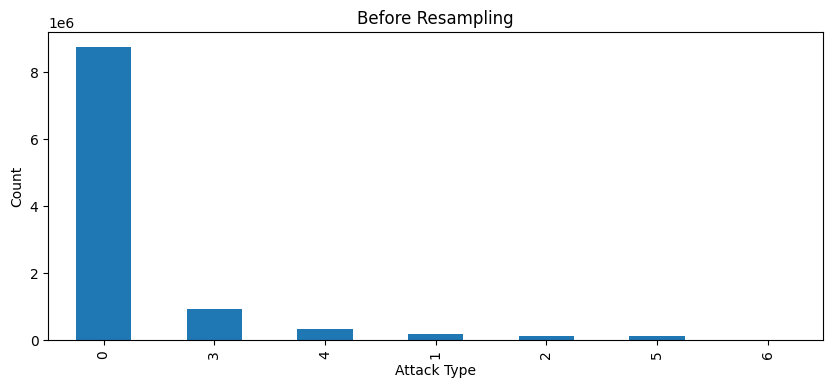

Original counts: Counter({0: 8757431, 3: 924193, 4: 313718, 1: 189061, 2: 115725, 5: 114521, 6: 636})
Label 5: from 114521 → 229042
Label 6: from 636 → 3180

After SMOTE:
Counter({0: 1657854, 3: 924193, 4: 313718, 5: 229042, 1: 189061, 2: 115725, 6: 3180})

💾 Saved cleaned training data → boruta_SM_TL_train.csv
📊 Distribution AFTER:


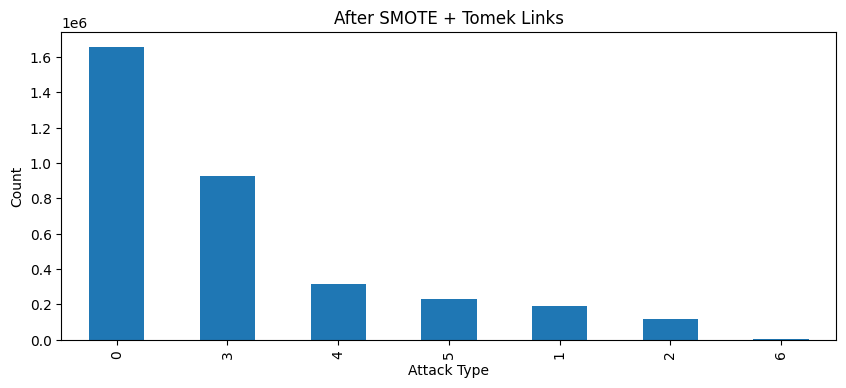


🔍 Starting XGBoost hyperparameter search...

Testing: n_estimators=100, max_depth=3, learning_rate=0.05


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:47:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98318

Testing: n_estimators=100, max_depth=3, learning_rate=0.1


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [02:48:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98647

Testing: n_estimators=100, max_depth=3, learning_rate=0.2


...

 → Validation Accuracy: 0.98521

Testing: n_estimators=300, max_depth=7, learning_rate=0.1


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:08:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98460

Testing: n_estimators=300, max_depth=7, learning_rate=0.2


C:\Users\henry\anaconda3\envs\r6g\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:09:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 → Validation Accuracy: 0.98397

Best Params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05}
Best Validation Accuracy: 0.9867241309121745

💾 Best model saved → D:/r6g/prog1/cicids2018M2/setb/xgb_SMOTE_Tomek_best_model2.pkl


In [8]:
# =====================================================
# Imports
# =====================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import accuracy_score
import xgboost as xgb
import joblib
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


# =====================================================
# Distribution Plot
# =====================================================
def plot_distribution(y, title):
    plt.figure(figsize=(10,4))
    pd.Series(y).value_counts().plot(kind='bar')
    plt.title(title)
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.show()


print("📊 Distribution BEFORE:")
plot_distribution(y_train, "Before Resampling")

print("Original counts:", Counter(y_train))


# ------------ Downsampling -----------------
train_data = X_train.copy()
train_data['Attack_Type'] = y_train.values

majority_class = train_data[train_data['Attack_Type'] == train_data['Attack_Type'].value_counts().idxmax()]
minority_class = train_data[train_data['Attack_Type'] != train_data['Attack_Type'].value_counts().idxmax()]

majority_downsampled = resample(
    majority_class,
    replace=False,
    n_samples=len(minority_class),
    random_state=42
)

train_balanced = pd.concat([majority_downsampled, minority_class])
X_train = train_balanced.drop(columns=['Attack_Type'])
y_train = train_balanced['Attack_Type']

# -----------------------------------------------------


# =====================================================
# 1️⃣ SMOTE — Increase Label 5 (+100%) & Label 6 (+500%)
# =====================================================

orig_c5 = Counter(y_train)[5]
orig_c6 = Counter(y_train)[6]

# 100% increase → new count = 2 × original
target_c5 = orig_c5 * 2

# 500% increase → new count = 5 × original
target_c6 = orig_c6 * 5

print(f"Label 5: from {orig_c5} → {target_c5}")
print(f"Label 6: from {orig_c6} → {target_c6}")

smote_strategy = {
    5: target_c5,
    6: target_c6
}

sm = SMOTE(
    sampling_strategy=smote_strategy,
    k_neighbors=5,
    random_state=42
)

X_sm, y_sm = sm.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(Counter(y_sm))


# # =====================================================
# # 2️⃣ Tomek Links — reduce majority classes
# # =====================================================
# tl = TomekLinks(sampling_strategy="majority")

# X_clean, y_clean = tl.fit_resample(X_sm, y_sm)

# print("\nAfter Tomek Links:")
# print(Counter(y_clean))


####### Bypass Tomek Links
X_clean = X_sm
y_clean = y_sm


# =====================================================
# 3️⃣ Save the cleaned training dataset
# =====================================================
boruta_SM_TL_train = pd.concat(
    [pd.DataFrame(X_clean, columns=X_train.columns),
     pd.Series(y_clean, name="Attack_Type")],
    axis=1
)

boruta_SM_TL_train.to_csv(datapath+"boruta_SM_TL_train.csv", index=False)
print("\n💾 Saved cleaned training data → boruta_SM_TL_train.csv")


# =====================================================
# 4️⃣ Plot final distribution
# =====================================================
print("📊 Distribution AFTER:")
plot_distribution(y_clean, "After SMOTE + Tomek Links")


# Replace training sets
X_train = X_clean
y_train = y_clean


# =====================================================
# 5️⃣ XGBoost Hyperparameter Search
# =====================================================
best_score = -1
best_params = None
best_model = None

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

print("\n🔍 Starting XGBoost hyperparameter search...\n")

for n in param_grid['n_estimators']:
    for md in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:

            print(f"Testing: n_estimators={n}, max_depth={md}, learning_rate={lr}")

            model = xgb.XGBClassifier(
                objective='multi:softprob',
                eval_metric='mlogloss',
                use_label_encoder=False,
                random_state=42,
                n_estimators=n,
                max_depth=md,
                learning_rate=lr
            )

            model.fit(X_train, y_train)

            y_pred_val = model.predict(X_val)
            val_acc = accuracy_score(y_val, y_pred_val)

            print(f" → Validation Accuracy: {val_acc:.5f}\n")

            if val_acc > best_score:
                best_score = val_acc
                best_params = {
                    'n_estimators': n,
                    'max_depth': md,
                    'learning_rate': lr
                }
                best_model = model


print("==========================================")
print("Best Params:", best_params)
print("Best Validation Accuracy:", best_score)


# =====================================================
# 6️⃣ Save the Best Model
# =====================================================
model_path = datapath+"xgb_SMOTE_Tomek_best_model2.pkl"
joblib.dump(best_model, model_path)
print(f"\n💾 Best model saved → {model_path}")


Loading model
Test metrics:
  Accuracy : 0.9807
  Precision: 0.9848
  Recall   : 0.9807
  F1-Score : 0.9815

Confusion Matrix (Raw Values):
[[2417233      70      46    1220     111    9843      30]
 [      0   45983       0       0       0       0       0]
 [      0       0   12012       0       0       0       0]
 [      0       0       0   91141       0       0       0]
 [    105       0   24703       0   94643       0       0]
 [  16130       0       1       7       0    1316       0]
 [     28       0       0       1       0       0     104]]

Confusion Matrix (Table with Original Attack Names):


,Pred Benign,Pred Bot,Pred Brute Force,Pred DDoS,Pred DoS,Pred Infiltration,Pred Web Attack
True Benign,2417233,70,46,1220,111,9843,30
True Bot,0,45983,0,0,0,0,0
True Brute Force,0,0,12012,0,0,0,0
True DDoS,0,0,0,91141,0,0,0
True DoS,105,0,24703,0,94643,0,0
True Infiltration,16130,0,1,7,0,1316,0
True Web Attack,28,0,0,1,0,0,104


<Figure size 1200x800 with 0 Axes>

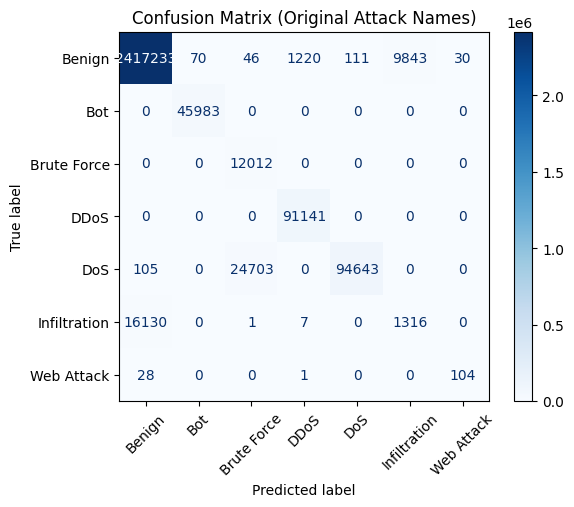

In [9]:
import joblib
import pandas as pd

# ===== Paths =====
model_path   = datapath+"xgb_SMOTE_Tomek_best_model2.pkl"

# ===== Load all objects =====
print("Loading model")

xgb_model = joblib.load(model_path)

# ===== Evaluate =====
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print("Test metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

# # ===== 8) Save artifacts =====
# joblib.dump(xgb_model, "D:/r6g/prog1/cicids2018/xgb_DS_best_model.pkl")

# print("Saved: xgb_model.pkl")

import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# ===== Load JSON mapping =====
with open("D:/r6g/prog1/cicids2018M2/mappings.json", "r") as f:
    mapping = json.load(f)

attack_type_mapping = mapping["attack_type_mapping"]   # dict: "0": "Benign", ...

# ===== Prepare label names (sorted by integer key) =====
unique_labels = sorted(list(set(y_test)))
attack_type_names = [attack_type_mapping[str(l)] for l in unique_labels]

# ===== Confusion Matrix =====
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

print("\nConfusion Matrix (Raw Values):")
print(cm)

# ===== Table Format =====
cm_df = pd.DataFrame(
    cm,
    index=[f"True {attack_type_mapping[str(l)]}" for l in unique_labels],
    columns=[f"Pred {attack_type_mapping[str(l)]}" for l in unique_labels]
)

print("\nConfusion Matrix (Table with Original Attack Names):")
display(cm_df)

# ===== Heatmap Plot =====
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=attack_type_names)
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Original Attack Names)")
plt.show()